In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.special as sc

In [ ]:
ws = pd.read_csv('Wind_Speed.csv')
ws = ws.iloc[:,4:5] # To get the data as a table rather than list (not mandatory)
ws

In [ ]:
k = (math.sqrt(np.mean(abs(ws-np.mean(ws))** 2 )) / np.mean(ws)) ** -1.086
print(k)

2.2309681647414084


In [ ]:
# Defining Weibull distribution
def weibull(x):
  k = (math.sqrt(np.mean(abs(ws-np.mean(ws))** 2 )) / np.mean(ws)) ** -1.086
  Gamma_F = math.exp(sc.gammaln(1 + (1 /k)))
  c = np.mean(ws) / Gamma_F
  return (k / c) * (x / c)** (k-1) * np.exp(-(x / c) ** (k))


Weibull = weibull(ws)
Weibull_df = pd.DataFrame(Weibull).rename(columns = {'WS10M':'Probability'})
Weibull_df

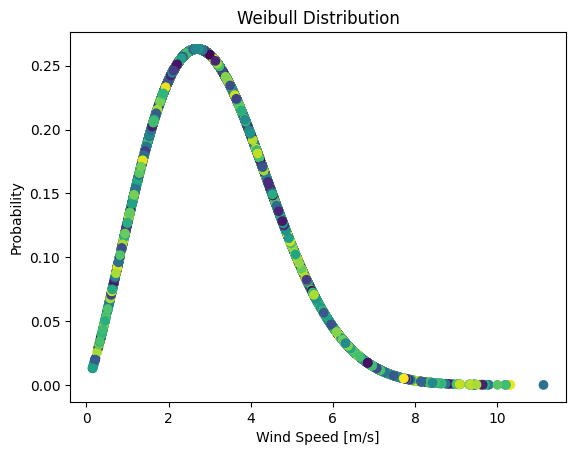

In [ ]:
N = 8760
colors = np.random.rand(N)

plt.scatter(ws, Weibull_df, c = colors, zorder = 2)
plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Probability")
plt.title("Weibull Distribution")
plt.show()